# Загрузка данных для мониторинга электропотребления Германии

**Проект:** мониторинг потребления электроэнергии на основе погодных условий и производственного календаря.

Тетрадка загружает открытые данные, сохраняет исходные ответы и метаданные, приводит данные к таблицам и формирует почасовую витрину. Запустите **Kernel → Restart & Run All**. Учётные записи и API-ключи не нужны. Требуются Python ≥ 3.10, доступ в интернет и возможность записи в текущую папку.

По умолчанию выбран `MODE = "demo"`: семь дней в конце последнего завершённого месяца и две области Германии. Это позволяет проверить все загрузчики, включая солнечные наблюдения, которые поступают с задержкой. Для исследования поменяйте режим на `"full"`: история с 2021 года и семь областей. Первая полная загрузка может занять десятки минут; объём зависит от размеров архивов DWD. Уже скачанные исторические файлы используются повторно.

| Набор | Источник и формат | Результат |
|---|---|---|
| Электрическая нагрузка Германии | Energy-Charts, HTTP/JSON, ряд `Load` | Мощность в МВт; почасовое потребление в МВт·ч |
| Температура и относительная влажность | DWD CDC, ZIP с CSV и метаданными | °C и % по станциям |
| Скорость и направление ветра | DWD CDC, ZIP с CSV и метаданными | м/с и градусы по станциям |
| Глобальная солнечная радиация и солнечное сияние | DWD CDC, ZIP с CSV и метаданными | Дж/см² и минуты по станциям |
| Прогноз погоды | DWD MOSMIX_L, KMZ/KML/XML | Температура, ветер, радиация; время выпуска и срок прогноза |
| Производственный календарь | Feiertage API, JSON по годам и землям | Даты, выходные, праздники, признаки рабочего дня |

**Границы интерпретации.** `Load` характеризует нагрузку энергосистемы, а не сумму счетчиков конечных потребителей. Календарь понедельник–пятница с исключением праздников — приближение рабочего режима, а не фактический график всех предприятий. Погода усредняется по выбранным областям с равными весами; это не официальное среднее по населению или промышленности Германии. Пропуски не заменяются нулями.


## 1. Зависимости и параметры
Если среда уже настроена, установка ничего не меняет. Все создаваемые данные находятся в `data_germany_energy/` рядом с тетрадкой. Для полной истории достаточно изменить `MODE`. Конец диапазона исключается: `[START, END)` в UTC.

**Настройка HTTPS.** Используются системное хранилище сертификатов через `truststore` и корневые сертификаты `certifi`. Контекст передаётся во все загрузки явно. Если в вашей сети HTTPS проверяется прокси или антивирусом и его сертификат ещё не доверен системой, задайте `CUSTOM_CA_FILE` — путь к полученному от администратора PEM-файлу корневого/промежуточного CA. Он добавляется к доверенным сертификатам. Проверка сертификата и имени сервера остаётся включённой.

После замены старой тетрадки выполните **Kernel → Restart & Run All**, чтобы прежняя функция `download` не осталась в памяти. Уже сохранённый каталог данных удалять не нужно. Если установка библиотек через pip тоже выдаёт ошибку сертификата, настройте доверенный CA для pip (`%pip install --cert "путь/ca.pem" certifi truststore`) и перезапустите ядро.


In [4]:
import importlib.util
import importlib.metadata
import subprocess
import sys

if sys.version_info < (3, 10):
    raise RuntimeError("Требуется Python 3.10 или новее для системного хранилища сертификатов")

requirements = {"pandas": "pandas>=2.2,<4", "numpy": "numpy>=1.26,<3",
                "matplotlib": "matplotlib>=3.7,<4", "tzdata": "tzdata", "IPython": "ipython>=8,<10",
                "certifi": "certifi>=2024.2.2", "truststore": "truststore>=0.10,<1"}
missing = [spec for module, spec in requirements.items()
           if importlib.util.find_spec(module) is None]
# В старых средах certifi может присутствовать, но содержать устаревший набор CA.
for package, minimum in {"certifi": (2024, 2), "truststore": (0, 10)}.items():
    if importlib.util.find_spec(package) is not None:
        version = tuple(int(p) for p in importlib.metadata.version(package).split(".")[:2])
        if version < minimum:
            missing.append(requirements[package])
if missing:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("Не удалось установить зависимости. Если pip сообщает SSL-ошибку, "
                           "настройте доверенный CA для pip по инструкции над этой ячейкой.") from exc

import os, io, re, json, time, uuid, hashlib, sqlite3, zipfile, socket
import urllib.request, urllib.error, urllib.parse, http.client, ssl
import certifi
import truststore
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime, timezone
from email.utils import parsedate_to_datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

CUSTOM_CA_FILE = os.environ.get("ENERGY_NOTEBOOK_CA_BUNDLE", "").strip()
# При необходимости замените пустую строку выше на путь к доверенному CA:
# CUSTOM_CA_FILE = r"C:\Certificates\organisation-ca.pem"

def make_ssl_context(custom_ca_file=""):
    context = truststore.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    context.load_verify_locations(cafile=certifi.where())
    if custom_ca_file:
        path = Path(custom_ca_file).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f"Файл CUSTOM_CA_FILE не найден: {path}")
        try:
            context.load_verify_locations(cafile=str(path))
        except (ssl.SSLError, OSError) as exc:
            raise ValueError("CUSTOM_CA_FILE должен содержать доверенные CA-сертификаты "
                             "в формате PEM, без закрытых ключей") from exc
    context.verify_mode = ssl.CERT_REQUIRED
    context.check_hostname = True
    context.minimum_version = ssl.TLSVersion.TLSv1_2
    return context

SSL_CONTEXT = make_ssl_context(CUSTOM_CA_FILE)

MODE = os.environ.get("ENERGY_NOTEBOOK_MODE", "full")  # "demo" или "full"
FULL_START = "2021-01-01"
LOCAL_TZ = "Europe/Berlin"
ROOT = Path(os.environ.get("ENERGY_NOTEBOOK_DATA", "data_germany_energy")).resolve()
TODAY = pd.Timestamp.now(tz=LOCAL_TZ).normalize()
if MODE == "demo":
    END = TODAY.replace(day=1).tz_convert("UTC").floor("h")
    START = END - pd.Timedelta(days=7)
elif MODE == "full":
    START = pd.Timestamp(FULL_START, tz=LOCAL_TZ).tz_convert("UTC")
    END = TODAY.tz_convert("UTC")
else:
    raise ValueError("MODE должен быть demo или full")
# Можно задать собственный период; обязательно укажите часовой пояс:
# START = pd.Timestamp("2025-01-01", tz=LOCAL_TZ).tz_convert("UTC")
# END = pd.Timestamp("2026-01-01", tz=LOCAL_TZ).tz_convert("UTC")
assert START < END and START >= pd.Timestamp("2021-01-01", tz=LOCAL_TZ).tz_convert("UTC")

HTTP_TIMEOUT = 180
MAX_ATTEMPTS = 4
MAX_RETRY_WAIT = 180
ENERGY_REQUEST_GAP = 31  # не более примерно двух обращений в минуту
RECENT_TTL_HOURS = 12
CATALOG_TTL_HOURS = 24
HISTORY_TTL_HOURS = 24 * 30  # периодически проверять исправления архивной истории
OVERLAP_DAYS = 7
PARSER_VERSION = "1.1"
RUN_ID = str(uuid.uuid4())
for folder in ["raw/objects", "raw/requests", "processed", "metadata", "quarantine"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
print(f"Режим: {MODE}; период UTC: {START} — {END} (конец исключён)")
print("Каталог данных:", ROOT)
print("HTTPS: системные CA + certifi; проверка сертификата и имени включена")
print("Дополнительный CA:", CUSTOM_CA_FILE or "не задан")


Режим: full; период UTC: 2020-12-31 23:00:00+00:00 — 2026-09-29 22:00:00+00:00 (конец исключён)
Каталог данных: C:\Users\Бобер\Documents\7_KURS\ПАС\data_germany_energy
HTTPS: системные CA + certifi; проверка сертификата и имени включена
Дополнительный CA: не задан


## 2. Общие функции: исходные файлы, повторы, журнал и идемпотентность

Исходные ответы хранятся по SHA-256 в `raw/objects/`; индекс запроса содержит URL, время, HTTP-заголовки и путь к объекту. Файлы записываются атомарно. Исторические ответы проверяются раз в 30 дней, изменяемые архивы — каждые 12 часов; прогнозы — каждый час. Удаление отдельного индекса в `raw/requests/` позволяет принудительно повторить конкретную загрузку.

`state.sqlite` хранит нормализованные записи, историю изменённых значений и журнал попыток. Ключи записей задаются явно; повтор того же ввода не создаёт бизнес-дубликатов. Перекрытие последних семи дней позволяет повторно получать исправления нагрузки. Сетевые ошибки, HTTP 429 и 5xx повторяются с ожиданием, учитывающим `Retry-After`. После исчерпания попыток ошибка сохраняется; остальные источники продолжают загружаться. Испорченный или неподдерживаемый файл сохраняется в карантине, а ранее загруженные записи остаются доступны.

Тетрадка повторно разбирает выбранные сохранённые архивы, но в базу добавляет только новые и изменившиеся строки. Это инкрементальная запись, а не скачивание отдельных новых строк из больших ZIP DWD: сервер предоставляет архив целиком.

До загрузки данных выполняется короткая HTTPS-проверка трёх серверов. Ошибка проверки сертификата останавливает выполнение сразу с указанием сервера и настройки `CUSTOM_CA_FILE`: бессмысленные повторы и вторичная ошибка «не удалось выбрать станции» не скрывают причину. Сетевые тайм-ауты и HTTP-ошибки по-прежнему обрабатываются отдельно.


In [5]:
def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256(data):
    return hashlib.sha256(data).hexdigest()

def atomic_bytes(path, data):
    path = Path(path)
    tmp = path.with_name(path.name + "." + uuid.uuid4().hex + ".tmp")
    tmp.write_bytes(data)
    os.replace(tmp, path)

def atomic_json(path, value):
    atomic_bytes(path, json.dumps(value, ensure_ascii=False, indent=2).encode("utf-8"))

DB = sqlite3.connect(ROOT / "state.sqlite", timeout=60)
DB.executescript("""
CREATE TABLE IF NOT EXISTS records (
 dataset TEXT NOT NULL, record_key TEXT NOT NULL, payload TEXT NOT NULL,
 business_hash TEXT NOT NULL, updated_at TEXT NOT NULL,
 PRIMARY KEY(dataset, record_key));
CREATE TABLE IF NOT EXISTS record_history (
 dataset TEXT, record_key TEXT, old_payload TEXT, new_hash TEXT, changed_at TEXT, run_id TEXT);
CREATE TABLE IF NOT EXISTS journal (
 id INTEGER PRIMARY KEY AUTOINCREMENT, run_id TEXT, started_at TEXT, finished_at TEXT,
 source TEXT, url TEXT, stage TEXT, status TEXT, attempt INTEGER, http_status INTEGER,
 bytes INTEGER, raw_sha256 TEXT, message TEXT);
""")
DB.commit()
ERRORS = []
LAST_REQUEST = {}

class TLSCertificateError(RuntimeError):
    """Сертификат не подтверждён; повтор без изменения доверенных CA не поможет."""

def is_certificate_error(exc):
    reason = getattr(exc, "reason", exc)
    return (isinstance(exc, ssl.SSLCertVerificationError)
            or isinstance(reason, ssl.SSLCertVerificationError)
            or "CERTIFICATE_VERIFY_FAILED" in str(reason))

def certificate_error(url, exc):
    host = urllib.parse.urlsplit(url).hostname or url
    return TLSCertificateError(
        f"HTTPS: не удалось подтвердить сертификат {host}. "
        "Используются системные CA и certifi. Если сеть использует сертификат прокси/антивируса, "
        "задайте CUSTOM_CA_FILE (доверенный PEM-файл CA) в первой ячейке, "
        "затем выполните Kernel → Restart & Run All. "
        f"Причина: {exc}")

def journal(source, url="", stage="download", status="ok", attempt=0,
            http_status=None, size=0, digest="", message="", started=None):
    with DB:
        DB.execute("INSERT INTO journal VALUES (NULL,?,?,?,?,?,?,?,?,?,?,?,?)",
                   (RUN_ID, started or utc_now(), utc_now(), source, url, stage,
                    status, attempt, http_status, size, digest, str(message)))

def retry_delay(header, attempt):
    delay = min(2 ** attempt + np.random.uniform(0, 1), MAX_RETRY_WAIT)
    if header:
        try:
            delay = float(header)
        except ValueError:
            delay = max(0, (parsedate_to_datetime(header) - datetime.now(timezone.utc)).total_seconds())
    if delay > MAX_RETRY_WAIT:
        raise RuntimeError(f"Retry-After={delay:.0f} с превышает лимит ожидания; повторите позже")
    return max(0, delay)

def download(url, source, ttl_hours=0):
    """Возвращает (bytes, SHA-256); не использует устаревший кеш при сетевой ошибке."""
    index = ROOT / "raw/requests" / (sha256(url.encode()) + ".json")
    try:
        old = json.loads(index.read_text()) if index.exists() else None
    except (OSError, json.JSONDecodeError) as exc:
        journal(source, url, stage="cache", status="error", message=str(exc))
        old = None
    if old:
        obj = ROOT / old["object_path"]
        if not obj.exists() or sha256(obj.read_bytes()) != old["sha256"]:
            old = None  # поврежденный локальный объект будет получен заново
        elif (pd.Timestamp.now(tz="UTC") - pd.Timestamp(old["checked_at"])).total_seconds() < ttl_hours * 3600:
            journal(source, url, status="cache", size=old["bytes"], digest=old["sha256"])
            return obj.read_bytes(), old["sha256"]
    headers = {"User-Agent": "GermanyEnergyResearchNotebook/1.0", "Accept-Encoding": "identity"}
    if old:
        if old.get("etag"): headers["If-None-Match"] = old["etag"]
        if old.get("last_modified"): headers["If-Modified-Since"] = old["last_modified"]
    for attempt in range(1, MAX_ATTEMPTS + 1):
        gap = ENERGY_REQUEST_GAP if source == "energy_charts" else 0.2
        elapsed = time.monotonic() - LAST_REQUEST.get(source, -1e9)
        if elapsed < gap: time.sleep(gap - elapsed)
        LAST_REQUEST[source] = time.monotonic()
        started = utc_now()
        retry_after = None
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=HTTP_TIMEOUT, context=SSL_CONTEXT) as response:
                body = response.read()
                if not body: raise ValueError("Пустой HTTP-ответ")
                digest = sha256(body)
                path = ROOT / "raw/objects" / digest
                if not path.exists(): atomic_bytes(path, body)
                meta = {"url": url, "source": source, "sha256": digest, "bytes": len(body),
                        "object_path": str(path.relative_to(ROOT)), "checked_at": utc_now(),
                        "retrieved_at": utc_now(), "http_status": response.status,
                        "content_type": response.headers.get("Content-Type"),
                        "etag": response.headers.get("ETag"),
                        "last_modified": response.headers.get("Last-Modified")}
                atomic_json(index, meta)
                journal(source, url, attempt=attempt, http_status=response.status,
                        size=len(body), digest=digest, started=started)
                return body, digest
        except urllib.error.HTTPError as exc:
            if exc.code == 304 and old:
                old["checked_at"] = utc_now()
                atomic_json(index, old)
                journal(source, url, status="not_modified", attempt=attempt, http_status=304,
                        size=old["bytes"], digest=old["sha256"], started=started)
                return (ROOT / old["object_path"]).read_bytes(), old["sha256"]
            journal(source, url, status="error", attempt=attempt, http_status=exc.code,
                    message=str(exc), started=started)
            if exc.code not in [408, 429, 500, 502, 503, 504] or attempt == MAX_ATTEMPTS:
                raise
            retry_after = exc.headers.get("Retry-After")
        except (urllib.error.URLError, ssl.SSLError, TimeoutError, socket.timeout, ConnectionError, http.client.IncompleteRead) as exc:
            journal(source, url, status="error", attempt=attempt, message=str(exc), started=started)
            if is_certificate_error(exc):
                raise certificate_error(url, exc) from exc
            if attempt == MAX_ATTEMPTS: raise
        time.sleep(retry_delay(retry_after, attempt))
    raise RuntimeError("Неожиданное окончание download")

def report_error(source, url, exc, digest=""):
    if isinstance(exc, TLSCertificateError):
        raise exc
    item = {"source": source, "url": url, "error": repr(exc), "raw_sha256": digest}
    ERRORS.append(item)
    journal(source, url, stage="pipeline", status="error", message=repr(exc), digest=digest)
    atomic_json(ROOT / "quarantine" / (uuid.uuid4().hex + ".json"), item)
    print(f"ОШИБКА [{source}]: {exc}")

def json_value(v):
    if v is None or pd.isna(v): return None
    if isinstance(v, (pd.Timestamp, datetime)): return v.isoformat()
    if isinstance(v, np.generic): return v.item()
    return v

def store_rows(dataset, frame, keys):
    if frame.empty:
        journal(dataset, stage="normalize", status="empty")
        return {"new": 0, "changed": 0, "unchanged": 0}
    if frame[keys].isna().any().any(): raise ValueError(f"{dataset}: пустой ключ")
    if frame.duplicated(keys).any(): raise ValueError(f"{dataset}: дубли ключей")
    old = dict(DB.execute("SELECT record_key,business_hash FROM records WHERE dataset=?", (dataset,)))
    updates, changes = [], []
    counts = {"new": 0, "changed": 0, "unchanged": 0}
    for row in frame.to_dict("records"):
        row = {k: json_value(v) for k, v in row.items()}
        key = json.dumps([row[k] for k in keys], ensure_ascii=False, separators=(",", ":"))
        business = {k:v for k,v in row.items() if k not in ["raw_sha256", "source_url"]}
        digest = sha256(json.dumps(business, sort_keys=True, ensure_ascii=False).encode())
        if old.get(key) == digest:
            counts["unchanged"] += 1
            continue
        payload = json.dumps(row, ensure_ascii=False, sort_keys=True)
        if key in old:
            counts["changed"] += 1
            changes.append((digest, utc_now(), RUN_ID, dataset, key))
        else: counts["new"] += 1
        updates.append((dataset, key, payload, digest, utc_now()))
    with DB:
        DB.executemany("""INSERT INTO record_history
            SELECT dataset,record_key,payload,?,?,? FROM records WHERE dataset=? AND record_key=?""", changes)
        DB.executemany("""INSERT INTO records VALUES (?,?,?,?,?)
            ON CONFLICT(dataset,record_key) DO UPDATE SET payload=excluded.payload,
            business_hash=excluded.business_hash,updated_at=excluded.updated_at""", updates)
    journal(dataset, stage="normalize", message=json.dumps(counts))
    return counts

def read_rows(dataset):
    return pd.DataFrame([json.loads(x[0]) for x in DB.execute(
        "SELECT payload FROM records WHERE dataset=? ORDER BY record_key", (dataset,))])

def export_csv(name, frame):
    path = ROOT / "processed" / (name + ".csv")
    atomic_bytes(path, frame.to_csv(index=False).encode("utf-8-sig"))
    return path

def in_period(frame, column="timestamp_utc"):
    if frame.empty: return frame
    out = frame.copy()
    out[column] = pd.to_datetime(out[column], utc=True)
    return out.loc[out[column].ge(START) & out[column].lt(END)].copy()

TLS_CHECKS = []
for url in ["https://api.energy-charts.info/", "https://opendata.dwd.de/", "https://feiertage-api.de/"]:
    try:
        request = urllib.request.Request(url, headers={"User-Agent": "GermanyEnergyResearchNotebook/1.1"})
        with urllib.request.urlopen(request, timeout=min(30, HTTP_TIMEOUT), context=SSL_CONTEXT) as response:
            response.read(1)
            status = "verified"
            http_status = response.status
        journal("https_check", url, stage="tls", status=status, http_status=http_status)
        TLS_CHECKS.append({"url":url, "status":status, "http_status":http_status})
        print("HTTPS OK:", urllib.parse.urlsplit(url).hostname)
    except urllib.error.HTTPError as exc:
        # Даже отказ HTTP означает, что проверка HTTPS уже пройдена.
        TLS_CHECKS.append({"url":url, "status":"verified_http_error", "http_status":exc.code})
        journal("https_check", url, stage="tls", status="verified_http_error", http_status=exc.code)
        print("HTTPS OK:", urllib.parse.urlsplit(url).hostname, "HTTP", exc.code)
    except (urllib.error.URLError, ssl.SSLError, TimeoutError, socket.timeout, ConnectionError) as exc:
        journal("https_check", url, stage="tls", status="error", message=str(exc))
        if is_certificate_error(exc):
            raise certificate_error(url, exc) from exc
        TLS_CHECKS.append({"url":url, "status":"network_error", "error":str(exc)})
        print("Проверка сети не завершена:", urllib.parse.urlsplit(url).hostname, exc)
        print("Загрузчик повторит сетевой запрос по обычным правилам.")
atomic_json(ROOT / "metadata/https_checks.json", TLS_CHECKS)
print("База и журнал готовы:", ROOT / "state.sqlite")


HTTPS OK: api.energy-charts.info
HTTPS OK: opendata.dwd.de
HTTPS OK: feiertage-api.de
База и журнал готовы: C:\Users\Бобер\Documents\7_KURS\ПАС\data_germany_energy\state.sqlite


## 3. Электрическая нагрузка — Energy-Charts

Из ответа `/public_power` выбирается только ряд с точным именем `Load`. Начало интервала берётся из `unix_seconds`, время хранится в UTC. Используется документированный формат v1; при смене схемы или флаге `deprecated` загрузка остановится с понятной ошибкой, а не подменит ряд другим показателем.

Запросы разбиты по календарным годам. Запрос последнего года разделён на устойчивую историческую часть и перекрытие последних семи дней. Точные UTC-границы передаются в API; клиент дополнительно фильтрует исключаемый конец. API может возвращать лишнюю граничную строку.


In [6]:
ENERGY_API = "https://api.energy-charts.info/public_power"

def energy_windows(start, end):
    cuts = {start, end}
    for year in range(start.year + 1, end.year + 1):
        point = pd.Timestamp(f"{year}-01-01", tz="UTC")
        if start < point < end: cuts.add(point)
    if end > pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=60):
        overlap = end - pd.Timedelta(days=OVERLAP_DAYS)
        if start < overlap < end: cuts.add(overlap)
    points = sorted(cuts)
    return list(zip(points[:-1], points[1:]))

def parse_energy(body, digest, url, start, end):
    obj = json.loads(body)
    if obj.get("deprecated"): raise ValueError("API v1 deprecated: требуется адаптация схемы")
    ts = pd.to_datetime(obj["unix_seconds"], unit="s", utc=True)
    series = [s for s in obj["production_types"] if s.get("name") == "Load"]
    if len(series) != 1: raise ValueError("Нет единственного ряда Load")
    if len(ts) != len(series[0]["data"]): raise ValueError("Длины временного ряда не совпадают")
    frame = pd.DataFrame({"timestamp_utc": ts,
                          "load_mw": pd.to_numeric(pd.Series(series[0]["data"]), errors="coerce")})
    frame = frame.loc[frame.timestamp_utc.ge(start) & frame.timestamp_utc.lt(end)].copy()
    frame = frame.sort_values("timestamp_utc")
    if frame.timestamp_utc.duplicated().any(): raise ValueError("Повтор временных меток Energy-Charts")
    if (frame.load_mw.dropna() < 0).any(): raise ValueError("Отрицательная нагрузка")
    # Формат v1 имеет шаг 15 или 60 минут; фиксируем его по регулярным соседним меткам.
    diffs = frame.timestamp_utc.diff().dropna().dt.total_seconds()
    if diffs.empty: raise ValueError("Недостаточно точек для определения шага")
    step = int(diffs.mode().iloc[0])
    if step not in [900, 3600] or (diffs % step != 0).any():
        raise ValueError(f"Неподдерживаемый шаг временного ряда: {step} с")
    frame["interval_seconds"] = step
    frame["raw_sha256"] = digest
    frame["source_url"] = url
    return frame

for left, right in energy_windows(START, END):
    url = ENERGY_API + "?" + urllib.parse.urlencode({"country":"de", "start":left.isoformat(),
                                                     "end":right.isoformat()})
    digest = ""
    try:
        recent = right > pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=OVERLAP_DAYS)
        body, digest = download(url, "energy_charts", RECENT_TTL_HOURS if recent else HISTORY_TTL_HOURS)
        frame = parse_energy(body, digest, url, left, right)
        print(left.date(), right.date(), store_rows("energy_load", frame, ["timestamp_utc"]))
    except Exception as exc:
        report_error("energy_charts", url, exc, digest)

load = in_period(read_rows("energy_load"))
if load.empty: raise RuntimeError("Нагрузка не загружена. Проверьте ERRORS и журнал; повторите ячейку.")
load = load.sort_values("timestamp_utc")
export_csv("energy_load_intervals", load)
display(load[["timestamp_utc", "load_mw", "interval_seconds"]].head())


2020-12-31 2021-01-01 {'new': 0, 'changed': 0, 'unchanged': 4}
2021-01-01 2022-01-01 {'new': 0, 'changed': 0, 'unchanged': 35040}
2022-01-01 2023-01-01 {'new': 0, 'changed': 0, 'unchanged': 35040}
2023-01-01 2024-01-01 {'new': 0, 'changed': 0, 'unchanged': 35040}
2024-01-01 2025-01-01 {'new': 0, 'changed': 0, 'unchanged': 35136}
2025-01-01 2026-01-01 {'new': 0, 'changed': 0, 'unchanged': 35040}
2026-01-01 2026-09-22 {'new': 0, 'changed': 0, 'unchanged': 25432}
2026-09-22 2026-09-29 {'new': 0, 'changed': 1, 'unchanged': 671}


,timestamp_utc,load_mw,interval_seconds
0,2020-12-31 23:00:00+00:00,44973.4,900
1,2020-12-31 23:15:00+00:00,44762.3,900
2,2020-12-31 23:30:00+00:00,44418.7,900
3,2020-12-31 23:45:00+00:00,44123.4,900
4,2021-01-01 00:00:00+00:00,43497.3,900


## 4. Каталоги и выбор метеостанций DWD CDC

Для каждой области и каждого параметра выбирается ближайшая действующая станция, чей каталог покрывает начало выбранного периода и заканчивается не ранее 65 дней назад. Отдельная станция выбирается для солнечных наблюдений, поскольку набор станций здесь иной. Координаты, расстояния и даты доступности сохраняются в `metadata/stations_selected.csv`. Каталог — предварительный фильтр; фактическое покрытие определяется после чтения данных. При небольшом собственном диапазоне тетрадка не гарантирует покрытие других дат.

В полном режиме используются Берлин, Гамбург, Франкфурт, Кёльн, Штутгарт, Лейпциг и Мюнхен. При повторном запуске на **том же диапазоне** сохранённый выбор станций фиксируется; для осознанного пересмотра удалите соответствующий `metadata/station_plan_*.json`.


In [7]:
CDC = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/"
VARIABLES = {
    "temperature": {"folder":"air_temperature", "code":"TU", "catalog":"TU_Stundenwerte_Beschreibung_Stationen.txt"},
    "wind": {"folder":"wind", "code":"FF", "catalog":"FF_Stundenwerte_Beschreibung_Stationen.txt"},
    "solar": {"folder":"solar", "code":"ST", "catalog":"ST_Stundenwerte_Beschreibung_Stationen.txt"},
}
CITIES = [
    {"city":"Berlin", "lat":52.52, "lon":13.405, "mosmix":"10384"},
    {"city":"Hamburg", "lat":53.551, "lon":9.994, "mosmix":"10147"},
    {"city":"Frankfurt", "lat":50.110, "lon":8.682, "mosmix":"10637"},
    {"city":"Cologne", "lat":50.938, "lon":6.960, "mosmix":"10513"},
    {"city":"Stuttgart", "lat":48.775, "lon":9.182, "mosmix":"10738"},
    {"city":"Leipzig", "lat":51.340, "lon":12.375, "mosmix":"10469"},
    {"city":"Munich", "lat":48.137, "lon":11.576, "mosmix":"10865"},
]
if MODE == "demo": CITIES = CITIES[:2]

def directory_links(url, source="dwd_cdc"):
    body, _ = download(url, source, CATALOG_TTL_HOURS)
    return [urllib.parse.urljoin(url, href) for href in re.findall(
        r'href=["\']([^"\']+)["\']', body.decode("utf-8", errors="replace"))]

def parse_station_catalog(body):
    rows = []
    for line in body.decode("latin1").splitlines():
        parts = line.split(maxsplit=6)
        if len(parts) < 7 or not re.fullmatch(r"\d{5}", parts[0]): continue
        rows.append({"station_id":parts[0], "from_date":parts[1], "to_date":parts[2],
                     "height_m":float(parts[3]), "lat":float(parts[4]), "lon":float(parts[5]),
                     "name_and_state":parts[6].strip()})
    if not rows: raise ValueError("Каталог станций пуст или схема изменилась")
    return pd.DataFrame(rows)

def distance_km(lat, lon, lat0, lon0):
    p1, p2 = np.radians(lat), np.radians(lat0)
    dlat, dlon = p1 - p2, np.radians(lon - lon0)
    a = np.sin(dlat/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

DIRECTORIES = {}
for variable, cfg in VARIABLES.items():
    try:
        if variable == "solar":
            urls = [CDC + cfg["folder"] + "/"]
        else:
            urls = [CDC + cfg["folder"] + "/recent/", CDC + cfg["folder"] + "/historical/"]
        DIRECTORIES[variable] = {url: directory_links(url) for url in urls}
    except Exception as exc:
        report_error("dwd_catalog", variable, exc)

plan_signature = sha256(json.dumps({"start":str(START), "end":str(END), "cities":CITIES}, sort_keys=True).encode())
plan_path = ROOT / "metadata" / ("station_plan_" + plan_signature[:16] + ".json")
if plan_path.exists():
    selected = pd.DataFrame(json.loads(plan_path.read_text()))
else:
    rows = []
    for variable, cfg in VARIABLES.items():
        if variable not in DIRECTORIES: continue
        url = CDC + cfg["folder"] + ("/" if variable == "solar" else "/recent/") + cfg["catalog"]
        try:
            body, _ = download(url, "dwd_cdc", CATALOG_TTL_HOURS)
            catalog = parse_station_catalog(body)
            cutoff = (min(END, pd.Timestamp.now(tz="UTC")) - pd.Timedelta(days=65)).strftime("%Y%m%d")
            eligible = catalog.loc[(catalog.from_date <= START.strftime("%Y%m%d")) & (catalog.to_date >= cutoff)].copy()
            available = set()
            for links in DIRECTORIES[variable].values():
                for link in links:
                    m = re.search(r"stundenwerte_" + cfg["code"] + r"_(\d{5})_", link)
                    if m: available.add(m.group(1))
            eligible = eligible.loc[eligible.station_id.isin(available)].copy()
            if eligible.empty: raise ValueError(f"Нет доступных станций {variable}, покрывающих период")
            for city in CITIES:
                ranked = eligible.assign(distance_km=distance_km(eligible.lat, eligible.lon, city["lat"], city["lon"]))
                row = ranked.sort_values(["distance_km", "station_id"]).iloc[0].to_dict()
                row.update(variable=variable, city=city["city"])
                rows.append(row)
        except Exception as exc:
            report_error("dwd_catalog", url, exc)
    selected = pd.DataFrame(rows)
    if selected.empty: raise RuntimeError("Не удалось выбрать станции")
    # Не фиксируем неполный план: после восстановления сети каталог будет пересчитан.
    if selected.variable.nunique() == len(VARIABLES): atomic_json(plan_path, rows)
atomic_bytes(ROOT / "metadata/stations_selected.csv", selected.to_csv(index=False).encode("utf-8-sig"))
display(selected[["variable", "city", "station_id", "distance_km", "to_date"]])


,variable,city,station_id,distance_km,to_date
0,temperature,Berlin,00433,5.830153,20260929
1,temperature,Hamburg,01975,9.148513,20260929
2,temperature,Frankfurt,01424,2.082888,20260929
3,temperature,Cologne,02667,16.081496,20260929
4,temperature,Stuttgart,04928,6.049838,20260929
5,temperature,Leipzig,02928,5.669217,20260929
6,temperature,Munich,03379,3.810159,20260929
7,wind,Berlin,00433,5.830153,20260929
8,wind,Hamburg,01975,9.148513,20260929
9,wind,Frankfurt,07341,7.757755,20260929


## 5. Наблюдения DWD: температура, влажность, ветер, радиация

Температура и ветер загружаются из `historical` и `recent`; при совпадении ключей более свежий файл заменяет значение. Для радиации используется общий архив `stundenwerte_ST_*_row.zip`, который содержит длинную историю и обновляется с задержкой. ZIP сохраняется целиком с метаданными, без распаковки произвольных путей на диск.

Значение `−999` становится `NaN`, код контроля качества `QN_*` сохраняется. Для диапазона с 2021 года временные метки DWD трактуются как UTC. У солнечного набора `MESS_DATUM` имеет формат с минутами и сохраняется без округления; `MESS_DATUM_WOZ` (истинное солнечное время) также остаётся в таблице. Радиация `FG_LBERG` измеряется в Дж/см²: умножение на `10 000 / 3 600` даёт Вт·ч/м² за исходный часовой интервал, а не мгновенную мощность.

Суммы радиации относятся к собственным интервалам DWD, которые могут не совпадать с границами гражданских часов. В итоговой витрине это **приближённый признак по часу опорной метки**, а не точная интеграция радиации в UTC-час. Для исследования этой зависимости используйте исходные минутные метки и метаданные архива.


In [8]:
def relevant_archives(variable, station_id):
    cfg = VARIABLES[variable]
    result = []
    for directory, links in DIRECTORIES.get(variable, {}).items():
        for url in links:
            filename = urllib.parse.urlsplit(url).path.rsplit("/", 1)[-1]
            if not re.match(r"stundenwerte_" + cfg["code"] + "_" + station_id + "_", filename): continue
            if not filename.endswith(".zip"): continue
            if "_hist.zip" in filename:
                match = re.search(r"_(\d{8})_(\d{8})_hist", filename)
                if match and (match.group(2) < START.strftime("%Y%m%d") or match.group(1) > END.strftime("%Y%m%d")):
                    continue
            result.append(url)
    # История сначала, recent после неё; солнечный архив единственный.
    return sorted(set(result), key=lambda u:("_akt.zip" in u, u))

def parse_cdc(body, variable, station_id, digest, url):
    chunks = []
    with zipfile.ZipFile(io.BytesIO(body)) as archive:
        product = [n for n in archive.namelist() if Path(n).name.startswith("produkt_") and n.endswith(".txt")]
        if len(product) != 1: raise ValueError("В ZIP нет единственного produkt_*.txt")
        with archive.open(product[0]) as stream:
            for frame in pd.read_csv(stream, sep=";", encoding="latin1", dtype={"MESS_DATUM":"string", "STATIONS_ID":"string"},
                                     na_values=[-999, "-999"], skipinitialspace=True, chunksize=100000):
                frame.columns = frame.columns.str.strip()
                stamp = frame["MESS_DATUM"].str.strip()
                fmt = "%Y%m%d%H:%M" if variable == "solar" else "%Y%m%d%H"
                frame["timestamp_utc"] = pd.to_datetime(stamp, format=fmt, utc=True, errors="raise")
                frame = in_period(frame)
                if frame.empty: continue
                ids = frame["STATIONS_ID"].str.strip().str.zfill(5)
                if not ids.eq(station_id).all(): raise ValueError("ID станции не соответствует архиву")
                out = pd.DataFrame({"station_id":station_id, "timestamp_utc":frame.timestamp_utc,
                                    "source_timestamp":stamp.loc[frame.index]})
                if variable == "temperature":
                    out["temperature_c"] = pd.to_numeric(frame["TT_TU"], errors="raise")
                    out["relative_humidity_pct"] = pd.to_numeric(frame["RF_TU"], errors="raise")
                    out["quality_code"] = frame["QN_9"]
                    if ((out.relative_humidity_pct.dropna() < 0) | (out.relative_humidity_pct.dropna() > 100)).any():
                        raise ValueError("Влажность вне диапазона 0–100%")
                elif variable == "wind":
                    out["wind_speed_ms"] = pd.to_numeric(frame["F"], errors="raise")
                    out["wind_direction_deg"] = pd.to_numeric(frame["D"], errors="raise")
                    out["quality_code"] = frame["QN_3"]
                    if (out.wind_speed_ms.dropna() < 0).any(): raise ValueError("Отрицательная скорость ветра")
                else:
                    out["global_radiation_j_cm2"] = pd.to_numeric(frame["FG_LBERG"], errors="raise")
                    out["solar_energy_wh_m2"] = out.global_radiation_j_cm2 * 10000 / 3600
                    out["sunshine_minutes"] = pd.to_numeric(frame["SD_LBERG"], errors="raise")
                    out["quality_code"] = frame["QN_592"]
                    out["timestamp_true_solar"] = frame["MESS_DATUM_WOZ"].astype("string").str.strip()
                out["raw_sha256"], out["source_url"] = digest, url
                chunks.append(out)
    if not chunks: return pd.DataFrame()
    frame = pd.concat(chunks, ignore_index=True).sort_values("timestamp_utc")
    if frame.duplicated(["station_id", "timestamp_utc"]).any(): raise ValueError("Дубли внутри архива DWD")
    return frame

for row in selected[["variable", "station_id"]].drop_duplicates().itertuples(index=False):
    archives = relevant_archives(row.variable, row.station_id)
    if not archives:
        report_error("dwd_" + row.variable, row.station_id, ValueError("Нет подходящего архива"))
    for url in archives:
        digest = ""
        try:
            ttl = HISTORY_TTL_HOURS if "_hist.zip" in url else RECENT_TTL_HOURS
            body, digest = download(url, "dwd_cdc", ttl)
            frame = parse_cdc(body, row.variable, row.station_id, digest, url)
            counts = store_rows("dwd_" + row.variable, frame, ["station_id", "timestamp_utc"])
            print(row.variable, row.station_id, url.rsplit("/",1)[-1], counts)
        except Exception as exc:
            report_error("dwd_" + row.variable, url, exc, digest)

observations = {}
for variable in VARIABLES:
    frame = in_period(read_rows("dwd_" + variable))
    # В базе может остаться история других планов; экспортируем текущий выбор станций.
    if not frame.empty:
        ids = selected.loc[selected.variable.eq(variable), "station_id"].tolist()
        frame = frame.loc[frame.station_id.isin(ids)].sort_values(["station_id", "timestamp_utc"])
    observations[variable] = frame
    export_csv("weather_" + variable + "_stations", frame)
    print(variable, "строк:", len(frame))


temperature 00433 stundenwerte_TU_00433_19510101_20251231_hist.zip {'new': 43825, 'changed': 0, 'unchanged': 0}
temperature 00433 stundenwerte_TU_00433_akt.zip {'new': 6526, 'changed': 0, 'unchanged': 6672}
temperature 01975 stundenwerte_TU_01975_19490101_20251231_hist.zip {'new': 43825, 'changed': 0, 'unchanged': 0}
temperature 01975 stundenwerte_TU_01975_akt.zip {'new': 6526, 'changed': 0, 'unchanged': 6672}
temperature 01424 stundenwerte_TU_01424_20080801_20251231_hist.zip {'new': 43825, 'changed': 0, 'unchanged': 0}
temperature 01424 stundenwerte_TU_01424_akt.zip {'new': 6526, 'changed': 0, 'unchanged': 6672}
temperature 02667 stundenwerte_TU_02667_19600101_20251231_hist.zip {'new': 43825, 'changed': 0, 'unchanged': 0}
temperature 02667 stundenwerte_TU_02667_akt.zip {'new': 6526, 'changed': 0, 'unchanged': 6672}
temperature 04928 stundenwerte_TU_04928_19770701_20251231_hist.zip {'new': 43825, 'changed': 0, 'unchanged': 0}
temperature 04928 stundenwerte_TU_04928_akt.zip {'new': 6526

## 6. Прогноз DWD MOSMIX_L

Загружается **доступный сейчас** выпуск MOSMIX_L для выбранных областей. KMZ содержит KML с временными метками и массивами прогнозных значений. Единицы дополнительно проверяются по `MetElementDefinition.xml`: `TTT` и `Td` — K, `FF` — м/с, `DD` — градусы, `Rad1h` — кДж/м². Температура переводится в °C; энергия радиации — в Вт·ч/м² делением на 3,6. Солнечный прогноз также имеет собственный опорный срок, поэтому не считается мгновенной мощностью.

Ключ прогноза: `(станция, время выпуска, срок действия)`. Новые выпуски добавляются, старые сохраняются. `LATEST` не даёт исторические прогнозы за 2021–2025 годы. Чтобы оценивать прогнозную модель без утечки будущего, запускайте сбор регулярно и при выборке используйте только выпуски, существовавшие на момент расчёта. Прогнозы не подмешиваются в исторические наблюдения.


In [9]:
MOSMIX_BASE = "https://opendata.dwd.de/weather/local_forecasts/mos/MOSMIX_L/single_stations/"
DEFINITIONS_URL = "https://opendata.dwd.de/weather/lib/MetElementDefinition.xml"
NS = {"k":"http://www.opengis.net/kml/2.2",
      "d":"https://opendata.dwd.de/weather/lib/pointforecast_dwd_extension_V1_0.xsd"}

def parse_mosmix(body, station_id, digest, url, units):
    expected = {"TTT":"K", "Td":"K", "FF":"m/s", "Rad1h":"kJ/m2"}
    for name, unit in expected.items():
        if units.get(name) != unit: raise ValueError(f"Единица {name} изменилась: {units.get(name)}")
    with zipfile.ZipFile(io.BytesIO(body)) as archive:
        names = [n for n in archive.namelist() if n.lower().endswith(".kml")]
        if len(names) != 1: raise ValueError("KMZ должен содержать один KML")
        root = ET.fromstring(archive.read(names[0]))
    issue = pd.to_datetime(root.findtext(".//d:IssueTime", namespaces=NS), utc=True)
    times = pd.to_datetime([x.text for x in root.findall(".//d:ForecastTimeSteps/d:TimeStep", NS)], utc=True)
    place = root.find(".//k:Placemark", NS)
    if place is None or place.findtext("k:name", namespaces=NS) != station_id:
        raise ValueError("MOSMIX: ID станции не совпадает")
    lon, lat, *_ = map(float, place.findtext("k:Point/k:coordinates", namespaces=NS).split(","))
    out = pd.DataFrame({"station_id":station_id, "issue_time_utc":issue, "valid_time_utc":times,
                        "station_name":place.findtext("k:description", namespaces=NS), "lat":lat, "lon":lon})
    fields = {"TTT":"temperature_c", "Td":"dewpoint_c", "FF":"wind_speed_ms",
              "DD":"wind_direction_deg", "Rad1h":"solar_energy_wh_m2"}
    found = set()
    for element in place.findall(".//d:Forecast", NS):
        name = element.get("{" + NS["d"] + "}elementName")
        if name not in fields: continue
        raw = element.findtext("d:value", namespaces=NS).split()
        if len(raw) != len(times): raise ValueError(f"MOSMIX: длина {name} не совпадает со сроками")
        values = pd.to_numeric(pd.Series([None if x == "-" else x for x in raw]), errors="raise").to_numpy()
        if name in ["TTT", "Td"]: values = values - 273.15
        if name == "Rad1h": values = values / 3.6
        out[fields[name]] = values
        found.add(name)
    if not set(fields).issubset(found): raise ValueError(f"MOSMIX: отсутствуют {set(fields)-found}")
    out["lead_hours"] = (out.valid_time_utc - out.issue_time_utc).dt.total_seconds()/3600
    out["raw_sha256"], out["source_url"] = digest, url
    return out

try:
    body, _ = download(DEFINITIONS_URL, "dwd_mosmix", CATALOG_TTL_HOURS)
    units = {}
    for element in ET.fromstring(body):
        values = {x.tag.split("}")[-1]:x.text for x in element}
        if "ShortName" in values: units[values["ShortName"]] = values.get("UnitOfMeasurement")
    atomic_json(ROOT / "metadata/mosmix_units.json", units)
    for city in CITIES:
        station = city["mosmix"]
        url = MOSMIX_BASE + f"{station}/kml/MOSMIX_L_LATEST_{station}.kmz"
        digest = ""
        try:
            body, digest = download(url, "dwd_mosmix", 1)
            frame = parse_mosmix(body, station, digest, url, units)
            print(city["city"], store_rows("mosmix_forecast", frame,
                                          ["station_id", "issue_time_utc", "valid_time_utc"]))
        except Exception as exc:
            report_error("dwd_mosmix", url, exc, digest)
except Exception as exc:
    report_error("dwd_mosmix", DEFINITIONS_URL, exc)

forecast = read_rows("mosmix_forecast")
if not forecast.empty:
    forecast = forecast.loc[forecast.station_id.isin([c["mosmix"] for c in CITIES])].copy()
    for column in ["issue_time_utc", "valid_time_utc"]:
        forecast[column] = pd.to_datetime(forecast[column], utc=True)
    latest_issue = forecast.groupby("station_id").issue_time_utc.transform("max")
    forecast_latest = forecast.loc[forecast.issue_time_utc.eq(latest_issue)].copy()
else: forecast_latest = forecast.copy()
export_csv("weather_forecast_all_issues", forecast)
export_csv("weather_forecast_latest", forecast_latest)
display(forecast_latest.head())


Berlin {'new': 247, 'changed': 0, 'unchanged': 0}
Hamburg {'new': 247, 'changed': 0, 'unchanged': 0}
Frankfurt {'new': 247, 'changed': 0, 'unchanged': 0}
Cologne {'new': 247, 'changed': 0, 'unchanged': 0}
Stuttgart {'new': 247, 'changed': 0, 'unchanged': 0}
Leipzig {'new': 247, 'changed': 0, 'unchanged': 0}
Munich {'new': 247, 'changed': 0, 'unchanged': 0}


,dewpoint_c,issue_time_utc,lat,lead_hours,lon,raw_sha256,solar_energy_wh_m2,source_url,station_id,station_name,temperature_c,valid_time_utc,wind_direction_deg,wind_speed_ms
0,11.0,2026-09-30 15:00:00+00:00,53.63,1.0,10.0,8612d1c148cf8e7ecdc8bb0556f4fb1e59b05c5aa52038...,133.333333,https://opendata.dwd.de/weather/local_forecast...,10147,HAMBURG-FU.,22.2,2026-09-30 16:00:00+00:00,110.0,4.63
1,11.1,2026-09-30 15:00:00+00:00,53.63,2.0,10.0,8612d1c148cf8e7ecdc8bb0556f4fb1e59b05c5aa52038...,33.333333,https://opendata.dwd.de/weather/local_forecast...,10147,HAMBURG-FU.,20.6,2026-09-30 17:00:00+00:00,106.0,4.12
2,11.1,2026-09-30 15:00:00+00:00,53.63,3.0,10.0,8612d1c148cf8e7ecdc8bb0556f4fb1e59b05c5aa52038...,0.000000,https://opendata.dwd.de/weather/local_forecast...,10147,HAMBURG-FU.,18.7,2026-09-30 18:00:00+00:00,108.0,4.12
3,11.0,2026-09-30 15:00:00+00:00,53.63,4.0,10.0,8612d1c148cf8e7ecdc8bb0556f4fb1e59b05c5aa52038...,0.000000,https://opendata.dwd.de/weather/local_forecast...,10147,HAMBURG-FU.,17.7,2026-09-30 19:00:00+00:00,104.0,4.12
4,10.8,2026-09-30 15:00:00+00:00,53.63,5.0,10.0,8612d1c148cf8e7ecdc8bb0556f4fb1e59b05c5aa52038...,0.000000,https://opendata.dwd.de/weather/local_forecast...,10147,HAMBURG-FU.,16.7,2026-09-30 20:00:00+00:00,102.0,4.12


## 7. Календарь Германии: 16 земель и общегосударственные праздники

API возвращает события отдельно для каждой земли и `NATIONAL`. Все события и пояснения сохраняются. Непустой `hinweis` считается **условным или требующим проверки событием**: это может быть праздник отдельных муниципалитетов, школьный день отдыха или другой особый случай. Такое событие не превращается автоматически в официальный нерабочий день всей земли. Для буднего дня с неразрешённым условным событием признак рабочего дня остаётся пустым.

Для ручной проверки можно заполнить `HOLIDAY_OVERRIDES` парами `(земля, название праздника)` → `True` (нерабочий день всей земли) или `False`. Источник Feiertage API опирается на справочную информацию; точные юридические условия отдельных праздников необходимо проверить по официальным правилам соответствующей земли. Школьные каникулы и сменные графики предприятий в этот календарь не входят.


In [10]:
CALENDAR_API = "https://feiertage-api.de/api/"
STATES = ["BW", "BY", "BE", "BB", "HB", "HH", "HE", "MV", "NI", "NW", "RP", "SL", "SN", "ST", "SH", "TH"]
HOLIDAY_OVERRIDES = {
    # ("BW", "Reformationstag"): False,  # пример; проверяйте конкретный hinweis
}

local_start = START.tz_convert(LOCAL_TZ).date()
local_last = (END - pd.Timedelta(microseconds=1)).tz_convert(LOCAL_TZ).date()
years = range(local_start.year, local_last.year + 1)

def calendar_frames(obj, year, digest, url):
    if not set(STATES + ["NATIONAL"]).issubset(obj): raise ValueError("Календарь: отсутствуют земли/NATIONAL")
    events = []
    for state in STATES + ["NATIONAL"]:
        for name, info in obj[state].items():
            date = pd.Timestamp(info["datum"]).date().isoformat()
            if pd.Timestamp(date).year != year: raise ValueError("Дата праздника вне запрошенного года")
            note = (info.get("hinweis") or "").strip()
            override = HOLIDAY_OVERRIDES.get((state, name))
            definite = state == "NATIONAL" or (override is True) or (not note and override is not False)
            conditional = bool(note) and override is None and state != "NATIONAL"
            events.append({"state":state, "date":date, "holiday_name":name, "note":note,
                           "definite":bool(definite), "conditional":conditional,
                           "manual_override":override, "raw_sha256":digest, "source_url":url})
    event_frame = pd.DataFrame(events)
    national = set(event_frame.loc[event_frame.state.eq("NATIONAL"), "date"])
    rows = []
    for day in pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D"):
        date = day.date().isoformat()
        weekend = day.dayofweek >= 5
        for state in STATES:
            day_events = event_frame.loc[event_frame.state.eq(state) & event_frame.date.eq(date)]
            definite = date in national or bool(day_events.definite.any())
            conditional = bool(day_events.conditional.any()) and not definite
            workday = False if weekend or definite else (None if conditional else True)
            rows.append({"date":date, "state":state, "weekday":int(day.dayofweek),
                         "is_weekend":bool(weekend), "is_national_holiday":date in national,
                         "is_state_holiday":definite, "has_conditional_event":conditional,
                         "is_workday_estimate":workday,
                         "holiday_names":" | ".join(day_events.holiday_name),
                         "raw_sha256":digest, "source_url":url})
    return event_frame, pd.DataFrame(rows)

for year in years:
    url = CALENDAR_API + "?" + urllib.parse.urlencode({"jahr":year})
    digest = ""
    try:
        body, digest = download(url, "calendar", CATALOG_TTL_HOURS * 7)
        events, days = calendar_frames(json.loads(body), year, digest, url)
        print(year, "события", store_rows("calendar_events", events, ["state", "date", "holiday_name"]))
        print(year, "дни", store_rows("calendar_states", days, ["state", "date"]))
    except Exception as exc:
        report_error("calendar", url, exc, digest)

calendar_events = read_rows("calendar_events")
calendar_states = read_rows("calendar_states")
if not calendar_events.empty:
    calendar_events = calendar_events.loc[calendar_events.date.str[:4].astype(int).isin(list(years))].copy()
if not calendar_states.empty:
    calendar_states = calendar_states.loc[calendar_states.date.ge(str(local_start)) &
                                          calendar_states.date.le(str(local_last))].copy()
export_csv("calendar_events", calendar_events)
export_csv("calendar_states", calendar_states)
if calendar_states.empty: raise RuntimeError("Календарь не загружен; проверьте ERRORS")

daily_rows = []
for date, group in calendar_states.groupby("date", sort=True):
    known = group.is_workday_estimate.notna()
    national = bool(group.is_national_holiday.any())
    weekend = bool(group.is_weekend.any())
    daily_rows.append({"date_local":date, "weekday":int(group.weekday.iloc[0]),
                       "is_weekend":weekend, "is_national_holiday":national,
                       "is_national_workday_estimate":not weekend and not national,
                       "workday_state_fraction_known":float(group.loc[known, "is_workday_estimate"].mean()) if known.any() else np.nan,
                       "n_states_calendar_known":int(known.sum()), "n_states_calendar_total":len(group)})
calendar_daily = pd.DataFrame(daily_rows)
export_csv("calendar_daily", calendar_daily)
display(calendar_daily.head())


ОШИБКА [calendar]: Дата праздника вне запрошенного года
ОШИБКА [calendar]: Дата праздника вне запрошенного года
ОШИБКА [calendar]: Дата праздника вне запрошенного года
2024 события {'new': 189, 'changed': 0, 'unchanged': 0}
2024 дни {'new': 5856, 'changed': 0, 'unchanged': 0}
2025 события {'new': 190, 'changed': 0, 'unchanged': 0}
2025 дни {'new': 5840, 'changed': 0, 'unchanged': 0}
2026 события {'new': 189, 'changed': 0, 'unchanged': 0}
2026 дни {'new': 5840, 'changed': 0, 'unchanged': 0}


,date_local,weekday,is_weekend,is_national_holiday,is_national_workday_estimate,workday_state_fraction_known,n_states_calendar_known,n_states_calendar_total
0,2024-01-01,0,False,True,False,0.0,16,16
1,2024-01-02,1,False,False,True,1.0,16,16
2,2024-01-03,2,False,False,True,1.0,16,16
3,2024-01-04,3,False,False,True,1.0,16,16
4,2024-01-05,4,False,False,True,1.0,16,16


## 8. Почасовая витрина и контроль качества

Мощность нагрузки переводится в энергию по длительности каждого исходного интервала: `МВт × секунды / 3 600 = МВт·ч`. Часовые показатели публикуются только при полном покрытии часа; для неполного часа итоговое потребление и средняя мощность остаются пустыми, частичная сумма вынесена в отдельный столбец. Это исключает ошибку «сумма четырёх мощностей = энергия за час».

Области имеют равные веса. Если одна станция выбрана для двух областей, её данные учитываются по одному разу на область, а число уникальных станций показывается отдельно. При пропусках среднее считается по доступным областям, поэтому рядом сохраняется их количество; используйте его для фильтрации качества. Направление ветра не усредняется арифметически.

Объединение выполняется по часам UTC. Календарная дата, час, смещение UTC и день недели определяются в `Europe/Berlin`: при смене времени сутки могут иметь 23 или 25 часов. UTC-ключ остаётся уникальным даже для повторяющегося местного часа. В витрину входят только наблюдения; прогнозы экспортируются отдельно.


In [11]:
def hourly_load(intervals):
    f = intervals.copy().sort_values("timestamp_utc")
    f["timestamp_utc"] = pd.to_datetime(f.timestamp_utc, utc=True)
    if f.timestamp_utc.duplicated().any(): raise ValueError("Нагрузка: повтор ключа времени")
    # Поддерживаются интервалы, полностью лежащие внутри UTC-часа.
    offsets = f.timestamp_utc.dt.minute * 60 + f.timestamp_utc.dt.second
    if (offsets + f.interval_seconds > 3600).any(): raise ValueError("Интервал пересекает границу часа")
    next_time = f.timestamp_utc.shift(-1)
    if ((f.timestamp_utc + pd.to_timedelta(f.interval_seconds, unit="s") > next_time).fillna(False)).any():
        raise ValueError("Перекрывающиеся интервалы нагрузки")
    f["timestamp_utc_hour"] = f.timestamp_utc.dt.floor("h")
    f["valid_seconds"] = np.where(f.load_mw.notna(), f.interval_seconds, 0)
    f["energy_piece_mwh"] = f.load_mw * f.interval_seconds / 3600
    h = f.groupby("timestamp_utc_hour").agg(
        covered_seconds=("valid_seconds", "sum"), intervals_received=("load_mw", "size"),
        partial_energy_mwh=("energy_piece_mwh", lambda s:s.sum(min_count=1))).reset_index()
    h = h.rename(columns={"timestamp_utc_hour":"timestamp_utc"})
    complete = h.covered_seconds.eq(3600)
    h["load_energy_mwh"] = h.partial_energy_mwh.where(complete)
    h["load_mean_mw"] = h.load_energy_mwh  # численно равно энергии за ровно один час
    h["load_hour_complete"] = complete
    return h

hours = pd.date_range(START.ceil("h"), END, freq="h", inclusive="left")
features = pd.DataFrame({"timestamp_utc":hours}).merge(hourly_load(load), on="timestamp_utc", how="left", validate="one_to_one")
features["load_hour_complete"] = features.load_hour_complete.fillna(False).astype(bool)

FEATURE_COLUMNS = {
    "temperature":["temperature_c", "relative_humidity_pct"],
    "wind":["wind_speed_ms"],
    "solar":["solar_energy_wh_m2", "sunshine_minutes"],
}
weather_summaries = []
for variable, columns in FEATURE_COLUMNS.items():
    frame = observations[variable]
    if frame.empty:
        for col in columns: features[col + "_mean"] = np.nan
        features[variable + "_n_stations"] = 0
        for col in columns: features[col + "_n_regions"] = 0
        continue
    f = frame.copy()
    f["timestamp_utc"] = f.timestamp_utc.dt.floor("h")
    # Сначала один показатель на станцию/опорный час, затем равное среднее по областям.
    station_hours = f.groupby(["station_id", "timestamp_utc"], as_index=False)[columns].mean()
    mapping = selected.loc[selected.variable.eq(variable), ["station_id", "city"]]
    region_hours = station_hours.merge(mapping, on="station_id", validate="many_to_many")
    aggregation = {}
    for col in columns:
        aggregation[col + "_mean"] = (col, "mean")
        aggregation[col + "_n_regions"] = (col, "count")
    aggregation[variable + "_n_stations"] = ("station_id", "nunique")
    summary = region_hours.groupby("timestamp_utc").agg(**aggregation).reset_index()
    weather_summaries.append(summary)
    features = features.merge(summary, on="timestamp_utc", how="left", validate="one_to_one")
    for col in [variable + "_n_stations"] + [c + "_n_regions" for c in columns]:
        features[col] = features[col].fillna(0).astype(int)

local = features.timestamp_utc.dt.tz_convert(LOCAL_TZ)
features["datetime_local"] = local.astype(str)
features["date_local"] = local.dt.strftime("%Y-%m-%d")
features["hour_local"] = local.dt.hour
features["utc_offset_minutes"] = local.map(lambda v:int(v.utcoffset().total_seconds()/60))
features = features.merge(calendar_daily, on="date_local", how="left", validate="many_to_one")
features["n_regions_selected"] = len(CITIES)
export_csv("features_hourly", features)

quality_rows = []
for name, frame in [("energy_load",load), *[("dwd_"+k,v) for k,v in observations.items()],
                    ("mosmix_forecast",forecast_latest), ("calendar_states",calendar_states)]:
    time_col = "valid_time_utc" if name == "mosmix_forecast" else ("date" if name == "calendar_states" else "timestamp_utc")
    keys = (["station_id", "issue_time_utc", "valid_time_utc"] if name == "mosmix_forecast" else
            ["state", "date"] if name == "calendar_states" else
            ["timestamp_utc"] if name == "energy_load" else ["station_id", "timestamp_utc"])
    quality_rows.append({"dataset":name, "rows":len(frame),
                         "duplicate_keys":int(frame.duplicated(keys).sum()) if not frame.empty else 0,
                         "first_timestamp":str(frame[time_col].min()) if not frame.empty else None,
                         "last_timestamp":str(frame[time_col].max()) if not frame.empty else None})
quality = pd.DataFrame(quality_rows)
export_csv("data_quality", quality)
missingness = pd.DataFrame({"column":features.columns, "missing_rows":features.isna().sum().to_numpy(),
                           "missing_fraction":features.isna().mean().to_numpy()})
export_csv("features_missingness", missingness)
display(quality)
display(features.head())
print("Полных часов нагрузки:", int(features.load_hour_complete.sum()), "из", len(features))
print("Солнечных часов с доступными данными:", int(features.solar_energy_wh_m2_mean.notna().sum()))


,dataset,rows,duplicate_keys,first_timestamp,last_timestamp
0,energy_load,201404,0,2020-12-31 23:00:00+00:00,2026-09-29 21:45:00+00:00
1,dwd_temperature,352456,0,2020-12-31 23:00:00+00:00,2026-09-29 21:00:00+00:00
2,dwd_wind,351414,0,2020-12-31 23:00:00+00:00,2026-09-29 21:00:00+00:00
3,dwd_solar,345347,0,2020-12-31 23:11:00+00:00,2026-08-31 23:31:00+00:00
4,mosmix_forecast,1729,0,2026-09-30 16:00:00+00:00,2026-10-10 22:00:00+00:00
5,calendar_states,16048,0,2024-01-01,2026-09-29


,timestamp_utc,covered_seconds,intervals_received,partial_energy_mwh,load_energy_mwh,load_mean_mw,load_hour_complete,temperature_c_mean,temperature_c_n_regions,relative_humidity_pct_mean,...,hour_local,utc_offset_minutes,weekday,is_weekend,is_national_holiday,is_national_workday_estimate,workday_state_fraction_known,n_states_calendar_known,n_states_calendar_total,n_regions_selected
0,2020-12-31 23:00:00+00:00,3600,4,44569.450,44569.450,44569.450,True,2.485714,7,84.000000,...,0,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,2021-01-01 00:00:00+00:00,3600,4,42806.100,42806.100,42806.100,True,2.214286,7,84.428571,...,1,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2,2021-01-01 01:00:00+00:00,3600,4,41049.725,41049.725,41049.725,True,1.914286,7,85.285714,...,2,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
3,2021-01-01 02:00:00+00:00,3600,4,40233.925,40233.925,40233.925,True,1.828571,7,85.000000,...,3,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
4,2021-01-01 03:00:00+00:00,3600,4,40210.675,40210.675,40210.675,True,1.728571,7,87.000000,...,4,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7


Полных часов нагрузки: 50351 из 50351
Солнечных часов с доступными данными: 49657


## 9. Проверка повторной записи и итог загрузки

Проверка ниже повторно записывает уже загруженные интервалы и требует нулевого числа новых/изменённых записей. Дополнительно проверяются размерность МВт → МВт·ч и 23/25-часовые сутки перехода времени. Журнал экспортируется в CSV; `metadata/run_<id>.json` содержит настройки, ошибки и список выходных файлов.

Наличие всех типов данных не означает полное покрытие каждой даты. Солнечные наблюдения часто заканчиваются раньше температуры и ветра; часы без опубликованных значений остаются пустыми. Оценивайте `data_quality.csv`, `features_missingness.csv` и счётчики областей перед обучением модели. При сбое устраните причину и запустите тетрадку снова с тем же каталогом данных: успешные загрузки сохраняются.


In [12]:
repeat = store_rows("energy_load", load, ["timestamp_utc"])
assert repeat["new"] == 0 and repeat["changed"] == 0, repeat
synthetic = pd.DataFrame({"timestamp_utc":pd.date_range("2025-01-01", periods=4, freq="15min", tz="UTC"),
                          "load_mw":[100.,100.,100.,100.], "interval_seconds":[900]*4})
assert hourly_load(synthetic).load_energy_mwh.iloc[0] == 100
synthetic.loc[2,"load_mw"] = np.nan
assert pd.isna(hourly_load(synthetic).load_energy_mwh.iloc[0])
for day, expected in [("2025-03-30",23),("2025-10-26",25)]:
    local_day = pd.Timestamp(day, tz=LOCAL_TZ)
    assert len(pd.date_range(local_day, local_day + pd.DateOffset(days=1), freq="h", inclusive="left")) == expected
assert not features.timestamp_utc.duplicated().any()
assert quality.duplicate_keys.eq(0).all()

run_log = pd.read_sql_query("SELECT * FROM journal WHERE run_id=? ORDER BY id", DB, params=(RUN_ID,))
export_csv("ingestion_journal_last_run", run_log)
export_csv("ingestion_journal_all_runs", pd.read_sql_query("SELECT * FROM journal ORDER BY id", DB))
manifest = {"run_id":RUN_ID, "finished_at":utc_now(), "mode":MODE, "start_utc":str(START), "end_utc_exclusive":str(END),
            "parser_version":PARSER_VERSION, "pandas_version":pd.__version__, "python_version":sys.version,
            "https_checks":TLS_CHECKS, "certificate_verification":True, "hostname_verification":True,
            "certifi_version":importlib.metadata.version("certifi"),
            "truststore_version":importlib.metadata.version("truststore"),
            "cities":CITIES, "station_plan":str(plan_path.relative_to(ROOT)),
            "errors":ERRORS, "quality":quality.to_dict("records"),
            "output_csvs":[str(p.relative_to(ROOT)) for p in sorted((ROOT/"processed").glob("*.csv"))]}
atomic_json(ROOT / "metadata" / ("run_" + RUN_ID + ".json"), manifest)
print("Повторная запись без изменений:", repeat)
print("Проверки энергии, ключей и перехода времени: пройдены")
print("Ошибок текущего запуска:", len(ERRORS))
if ERRORS: display(pd.DataFrame(ERRORS))
print("Выходные файлы:")
for path in sorted((ROOT / "processed").glob("*.csv")):
    print(" ", path.name)
required_empty = quality.loc[quality.rows.eq(0), "dataset"].tolist()
if required_empty:
    raise RuntimeError("Не загружены обязательные группы: " + ", ".join(required_empty) + ". Проверьте журнал и повторите запуск.")
print("Все требуемые группы данных доступны; покрытие периода показано в data_quality.csv.")


Повторная запись без изменений: {'new': 0, 'changed': 0, 'unchanged': 201404}
Проверки энергии, ключей и перехода времени: пройдены
Ошибок текущего запуска: 3


,source,url,error,raw_sha256
0,calendar,https://feiertage-api.de/api/?jahr=2021,ValueError('Дата праздника вне запрошенного го...,3fc02fae18b23ddb1810e4c20d027563ae081c68382789...
1,calendar,https://feiertage-api.de/api/?jahr=2022,ValueError('Дата праздника вне запрошенного го...,a77922b0fc4a3686ee21c84f0dde88405c95ebe53935d2...
2,calendar,https://feiertage-api.de/api/?jahr=2023,ValueError('Дата праздника вне запрошенного го...,7287dfb96b7e8d90364801f7f2a67c39bf457c16b79a9b...


Выходные файлы:
  calendar_daily.csv
  calendar_events.csv
  calendar_states.csv
  data_quality.csv
  energy_load_intervals.csv
  features_hourly.csv
  features_missingness.csv
  ingestion_journal_all_runs.csv
  ingestion_journal_last_run.csv
  weather_forecast_all_issues.csv
  weather_forecast_latest.csv
  weather_solar_stations.csv
  weather_temperature_stations.csv
  weather_wind_stations.csv
Все требуемые группы данных доступны; покрытие периода показано в data_quality.csv.


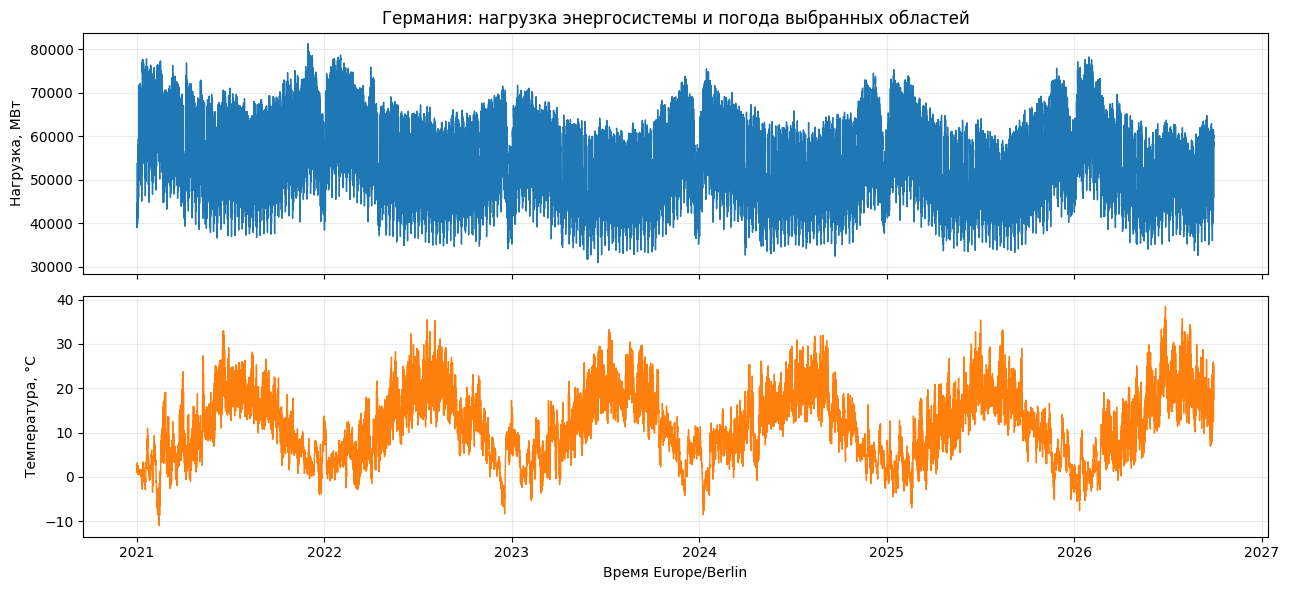

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
x = features.timestamp_utc.dt.tz_convert(LOCAL_TZ)
axes[0].plot(x, features.load_mean_mw, linewidth=1)
axes[0].set(ylabel="Нагрузка, МВт", title="Германия: нагрузка энергосистемы и погода выбранных областей")
axes[1].plot(x, features.temperature_c_mean, color="tab:orange", linewidth=1)
axes[1].set(ylabel="Температура, °C", xlabel="Время Europe/Berlin")
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 10. Состав результатов и дальнейшее использование

- `energy_load_intervals.csv` — исходный шаг нагрузки, мощность, длительность интервала и происхождение.
- `weather_temperature_stations.csv`, `weather_wind_stations.csv`, `weather_solar_stations.csv` — наблюдения по станциям с кодами качества и SHA-256 исходных архивов.
- `weather_forecast_all_issues.csv` и `weather_forecast_latest.csv` — накопленные и последние выпуски прогнозов.
- `calendar_events.csv`, `calendar_states.csv`, `calendar_daily.csv` — события, календарь земель и общегерманские признаки.
- `features_hourly.csv` — данные для мониторинга и анализа: нагрузка, наблюдаемая погода, календарь и полнота.
- `data_quality.csv`, `features_missingness.csv`, `ingestion_journal_*.csv` — покрытие, пропуски и журнал.
- `raw/`, `metadata/`, `quarantine/`, `state.sqlite` — исходные объекты, метаданные, проблемные загрузки, состояние и история изменений.

Для регулярного обновления запускайте тетрадку ежедневно в режиме `full`, сохраняя каталог данных. Частые запуски MOSMIX можно вынести в отдельное задание. SQLite и индексы рассчитаны на одного писателя: не запускайте два экземпляра одновременно в одной папке. Файлы CSV читаются с `encoding="utf-8-sig"`; временные поля после чтения нужно восстановить через `pd.to_datetime(..., utc=True)`.

План станций привязан к точному диапазону. При ежедневном расширении диапазона каталог повторно выбирает ближайшие подходящие станции; сравнивайте планы, если состав сети изменился. Для стабильного длительного исследования фиксируйте выбранные станции и область усреднения до построения обучающей выборки. Сохранённая база может содержать более ранние периоды, но CSV наблюдений и витрина экспортируются только для текущего диапазона. Отсутствующие в новой версии источника ключи автоматически не удаляются: удаление следует рассматривать как отдельную проверяемую коррекцию.

При прогнозировании разделяйте обучение и проверку по времени. Использование будущих фактических наблюдений вместо доступного тогда выпуска прогноза даёт утечку информации. Ряд нагрузки также может позднее исправляться; исходные объекты, журнал и история базы помогают восстановить использованные версии.

## Первичные описания источников

1. [Energy-Charts API и схема](https://api.energy-charts.info/) — данные и единицы мощности; [OpenAPI](https://api.energy-charts.info/openapi.json). Указывайте Energy-Charts.info при использовании; актуальные условия доступны в описании API.
2. [DWD CDC: температура и влажность](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/air_temperature/), [ветер](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/wind/), [радиация](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/solar/). Описания наборов и метаданные входят в каталоги и ZIP.
3. [DWD MOSMIX_L: станции и выпуски](https://opendata.dwd.de/weather/local_forecasts/mos/MOSMIX_L/single_stations/), [определения метеопараметров и единиц](https://opendata.dwd.de/weather/lib/MetElementDefinition.xml).
4. [Feiertage API: параметры и ограничения](https://feiertage-api.de/).

Настройка HTTPS: [truststore — системные хранилища сертификатов](https://truststore.readthedocs.io/en/latest/), [Python ssl — проверка сертификата и имени сервера](https://docs.python.org/3/library/ssl.html), [certifi — набор корневых CA](https://github.com/certifi/python-certifi).

При подготовке отчёта фиксируйте дату обращения, фактический диапазон каждой таблицы и сведения о выбранных станциях из результатов запуска. Тетрадка является приложением к проекту; оформление основной главы по нормоконтролю выполняется в отчётном документе.


## Сведения о проверке этой версии

Тетрадка выполнена в Jupyter-ядре на реальных данных 30.09.2026. Для периода 25–31 августа 2026 года (Europe/Berlin) получены 672 интервала нагрузки и 168 полных часов, по 336 записей каждого набора наблюдений (две области), 494 прогнозные записи последнего выпуска и календарь 16 земель. Повторный запуск не изменил бизнес-данные; проверки размерности энергии и перехода времени пройдены.

Версия 1.1 добавляет единый HTTPS-контекст с системными CA, certifi и необязательным дополнительным PEM. Для этой версии проверены реальные HTTPS-подключения ко всем трём источникам, отклонение недоверенного сертификата, загрузка с явно добавленным тестовым CA и отклонение сертификата с неверным именем сервера. Проверка не выполнялась на компьютере пользователя; если сеть использует свой CA, его нужно доверить системе или указать в CUSTOM_CA_FILE.

Отдельно проверены подбор станций для всех семи областей, все семь загрузок MOSMIX, годовой ответ Energy-Charts за 2021 год (35 040 интервалов), а также исторические архивы температуры и ветра станции 00433 с 2021 по 2025 год. Вся многолетняя история по всем станциям при проверке не скачивалась. При новом запуске демонстрационный период и доступный выпуск прогноза вычисляются заново.
